In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
# import cupy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.visualization import ImageNormalize, SqrtStretch

# import sunpy.coordinates  # NOQA
import sunpy.map
from sunpy.net import Fido
from sunpy.net import attrs as a
import sunpy.map
from matplotlib.patches import ConnectionPatch

import datetime
from scipy.io import loadmat, savemat
import scipy
from aiapy.calibrate import degradation, register, update_pointing, correct_degradation
from aiapy.calibrate.util import get_correction_table

from wavelet2DT_GPU import cwt2DT
%matplotlib inline


def calibrate_map(aia_map):
    aiamap_updated = update_pointing(aia_map)
    aiamap_registered = register(aiamap_updated)
    aiamap_calibrated = correct_degradation(aiamap_registered)/aiamap_registered.exposure_time
    return aiamap_calibrated

def transform_to_helioprojective_radial(old_map):
        # 投影到r-theta的函数
        # Calculate the number of bins in radius and azimuth
        radius_bin_size = old_map.scale[0].to_value('arcsec/pix')*2
        max_radius_arcsec = 1300
        num_radius_bins = int(max_radius_arcsec / radius_bin_size)
        num_azimuth_bins = 1080
        # Define a WCS header that uses the plate carrée cylindrical projection
        # oriented such that its pole is at disk center
        new_header = {
            'naxis': 2,
            'ctype1': 'HPLN-CAR',
            'naxis1': num_azimuth_bins,
            'cdelt1': 360 / num_azimuth_bins,
            'cunit1': 'deg',
            'crpix1': num_azimuth_bins / 2 + 0.5,
            'crval1': 0,
            'ctype2': 'HPLT-CAR',
            'naxis2': num_radius_bins,
            'cdelt2': radius_bin_size,
            'cunit2': 'arcsec',
            'crpix2': num_radius_bins + 0.5 - 90 * 3600/ (radius_bin_size),
            'crval2': -90*3600,
            'date-obs': old_map.date.utc.isot,
            'mjdref': 0,
            'dsun_obs': old_map.observer_coordinate.radius.to_value('m'),
            'hgln_obs': old_map.observer_coordinate.lon.to_value('deg'),
            'hglt_obs': old_map.observer_coordinate.lat.to_value('deg'),
            'rsun_ref': old_map.rsun_meters.value,
        }

        new_map = old_map.reproject_to(new_header)
        return new_map

def project_aia_map(squence_map):
    projected_sequence = np.array([])
    for aia_map in squence_map:
        new_map = transform_to_helioprojective_radial(aia_map)
        projected_sequence = np.append(projected_sequence, new_map)
    print('Finished: project_aia_map')
    return projected_sequence

def calibrate_aia_map_sequence(squence_map):
    calibrated_sequence = np.array([])
    num_temp = 0
    for aia_map in squence_map:
        print(num_temp)
        aiamap_calibrated = calibrate_map(aia_map)
        calibrated_sequence = np.append(calibrated_sequence, aiamap_calibrated)
        num_temp = num_temp + 1
    print('Finished: calibrate_aia_map_sequence')
    return calibrated_sequence

def get_radial_azimuth_arr(new_map):
    data_shape = np.shape(new_map.data)
    azimuth_arr = 180 + (np.arange(data_shape[1]) - new_map.fits_header['CRPIX1'])*new_map.fits_header['CDELT1'] + new_map.fits_header['CRVAL1']
    radial_degree_arr = np.flip((np.arange(data_shape[0]) - new_map.fits_header['CRPIX2'])*new_map.fits_header['CDELT2'] + new_map.fits_header['CRVAL2'])
    radial_Rs_arr = np.abs(np.tan(radial_degree_arr/180*np.pi)*new_map.fits_header['DSUN_OBS']/new_map.fits_header['RSUN_REF'])
    # print('radialRs: ',radial_Rs_arr)
    return radial_Rs_arr, azimuth_arr
    
def get_submap_data(deg_min,deg_max,r_min,r_max,new_map):
    radial_Rs_arr, azimuth_arr = get_radial_azimuth_arr(new_map)

    deg_min_index = np.argmin(np.abs(azimuth_arr-deg_min))
    deg_max_index = np.argmin(np.abs(azimuth_arr-deg_max))
    r_min_index = np.argmin(np.abs(radial_Rs_arr-r_min))
    r_max_index = np.argmin(np.abs(radial_Rs_arr-r_max))
    new_map_data = np.flip(np.copy(new_map.data), axis=0)
    submap_data = new_map_data[r_min_index:r_max_index+1,deg_min_index:deg_max_index+1]
    sub_radial_Rs_arr = radial_Rs_arr[r_min_index:r_max_index+1]
    sub_azimuth_arr = azimuth_arr[deg_min_index:deg_max_index+1]
    return sub_radial_Rs_arr,sub_azimuth_arr,submap_data

def crop_lasco_map(squence_map,deg_min,deg_max,r_min,r_max):
    # crop_lasco_map(self, sequence, deg_min=60, deg_max = 120, r_min = 2.4, r_max = 6.3, ):
    # 裁剪出所选区域
    # deg_min = self.phiMin.value()#float(self.phiMin.toPlainText())
    # deg_max = self.phiMax.value()#float(self.phiMax.toPlainText())
    # r_min = self.radialMin.value()#float(self.radialMin.toPlainText())
    # r_max = self.radialMax.value()#float(self.radialMax.toPlainText())
    subsequence_data_is_empty = True
    sequence_map_datetime = np.array([])
    for map_idx in range(np.shape(squence_map)[0]):
        temp_map = squence_map[map_idx]
        sub_radial_Rs_arr, sub_azimuth_arr, submap_data = get_submap_data(deg_min = deg_min,
                                                                            deg_max = deg_max,
                                                                            r_min = r_min,
                                                                            r_max = r_max, 
                                                                            new_map = temp_map)
        map_datetime = datetime.datetime.strptime(temp_map.date.utc.isot,"%Y-%m-%dT%H:%M:%S.%f")
        
        if subsequence_data_is_empty:
            subsequence_data = np.copy(submap_data)
            subsequence_data_is_empty = False
            sequence_map_datetime = np.append(sequence_map_datetime, map_datetime)
        else:
            subsequence_data = np.dstack([subsequence_data, submap_data])
            sequence_map_datetime = np.append(sequence_map_datetime, map_datetime)
    print('Finished: crop_lasco_map')
    return sub_radial_Rs_arr, sub_azimuth_arr, sequence_map_datetime, subsequence_data

def calculate_wavelet_2DT_GPU(sequence_data):
    load_data_file = loadmat("D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat")
    input_data_3D = load_data_file['data'][...]
    # sequence_time = load_data_file['crop_sequence_jualin_time'][...]
    dx = 1 # load_data_file['dx'][-1][0]
    dy = 1 # load_data_file['dy'][-1][0]
    dt = 12
    # input_data_3D = np.transpose(sequence_data, (1,0,2))
    fft_3D_out = scipy.fft.fftn(input_data_3D, axes=(0,1,2)) #fft变换结果数组shape和原数据保持一致
    
    freq_sample_spatial_x = 1.0/dx
    freq_sample_spatial_y = 1.0/dy
    freq_sample_spatial_t = 1.0/dt

    lambda_r_arr = np.logspace(np.log10(2),np.log10(150), 10, base=10) ### modified by user
    lambda_t_arr = np.logspace(np.log10(2),np.log10(150), 10, base=10) ### modified by user
    period_arr = np.logspace(np.log10(12),np.log10(600), 20, base=10) ### modified by user

    lambda_r_arr = np.hstack((np.flip(-lambda_r_arr), lambda_r_arr))
    lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
    period_arr=  np.append(period_arr, -2*np.pi/0.01)
    
    dlambda_theta = np.abs(np.append(0, np.diff(lambda_t_arr)))

    k_lambda_r = 5
    step_lambda_r = int(np.ceil(lambda_r_arr.size/k_lambda_r))
    k_lambda_t = 5
    step_lambda_t = int(np.ceil(lambda_t_arr.size/k_lambda_t))
    k_period = 5
    step_period = int(np.ceil(period_arr.size/k_period))
    
    for i_lambda_r in range(k_lambda_r):
        for i_lambda_t in range(k_lambda_t):
            for i_period in range(k_period):
                # for i_rot_angle in range(k_rot_angle):
                input_lambda_r_arr = lambda_r_arr[step_lambda_r*i_lambda_r:step_lambda_r*(i_lambda_r+1)]
                input_lambda_t_arr = lambda_t_arr[step_lambda_t*i_lambda_t:step_lambda_t*(i_lambda_t+1)]
                input_period_arr = period_arr[step_period*i_period:step_period*(i_period+1)]
                input_dlambda_theta = dlambda_theta[step_lambda_t*i_lambda_t:step_lambda_t*(i_lambda_t+1)]
                # input_rot_angle_arr = rot_angle_arr[step_rot_angle*i_rot_angle:step_rot_angle*(i_rot_angle+1)]
                ## 作2D+T的morlet小波变换
                output_2DT_partial = cwt2DT(fft_3D_out,
                                   freq_sample_spatial_x=freq_sample_spatial_x,
                                   freq_sample_spatial_y=freq_sample_spatial_y,
                                   freq_sample_time=freq_sample_spatial_t,
                                   lambda_r_arr=input_lambda_r_arr, lambda_t_arr=input_lambda_t_arr, period_arr=input_period_arr,
                                   ) #  unit of angle: degree
                # dk_theta = np.abs(np.append(np.diff(2*np.pi/input_lambda_t_arr), 0))
                dim_array = np.ones((1, output_2DT_partial.ndim), int).ravel()
                dim_array[4] = -1
                input_dlambda_theta_reshaped = input_dlambda_theta.reshape(dim_array)

                output_2DT_partial_intergrated_on_k_theta = np.sum(np.abs(output_2DT_partial)**2 * input_dlambda_theta_reshaped, axis=4)
                
                dtime = 1 # unit: frame
                output_2DT_partial_intergrated_on_k_theta_low_time_cadence = output_2DT_partial_intergrated_on_k_theta[:,:,::dtime,:,:]
                mdic = {"data": output_2DT_partial_intergrated_on_k_theta_low_time_cadence, "input_lambda_r_arr": input_lambda_r_arr,
                        "input_lambda_t_arr": input_lambda_t_arr,
                         "input_period_arr": input_period_arr, 
                         }

                print(np.shape(output_2DT_partial_intergrated_on_k_theta))
                savemat("D:/work/wavelet/data/wavelet_output/output_2DT_partial_"+str(i_lambda_r)+"_lambda_r_"+str(i_lambda_t)+"_lambda_t_"+str(i_period)+"_period.mat", mdic)
                print("D:/work/wavelet/data/wavelet_output/output_2DT_partial_"+str(i_lambda_r)+"_lambda_r_"+str(i_lambda_t)+"_lambda_t_"+str(i_period)+"_period.mat")
                del mdic
                del output_2DT_partial

def get_parameter_index_in_np_array(array, sub_array):
    sub_idx = np.array([],dtype=int)
    for i in sub_array:
        sub_idx = np.append(sub_idx, int(np.where(np.abs(array-i)<1e-3)[-1]))
    return sub_idx

def combine_wavelet_output(azimuth_degree,radial_Rs):

    dir_wavelet_output = 'D:/work/wavelet/data/wavelet_output/'
    wavelet_output_filelist = os.listdir(dir_wavelet_output)
    current_point_is_in_wavelet_output, azimuth_idx, radial_idx, x_azimuth_arr, y_radial_arr = \
                        check_current_point_is_in_wavelet_output(azimuth_degree, radial_Rs)
    print('current_point_is_in_wavelet_output',current_point_is_in_wavelet_output)
    if current_point_is_in_wavelet_output:
        lambda_r_arr = np.logspace(np.log10(2),np.log10(150), 10, base=10) ### modified by user
        lambda_t_arr = np.logspace(np.log10(2),np.log10(150), 10, base=10) ### modified by user
        period_arr = np.logspace(np.log10(12),np.log10(600), 20, base=10) ### modified by user

        lambda_r_arr = np.hstack((np.flip(-lambda_r_arr), lambda_r_arr))
        lambda_t_arr = np.hstack((np.flip(-lambda_t_arr), lambda_t_arr))
        period_arr=  np.append(period_arr, -2*np.pi/0.01)

        data_combined = np.zeros(shape=(y_radial_arr.size, 51, lambda_r_arr.size, period_arr.size)) ## 13??
        
        for file in wavelet_output_filelist:
            print(file)
            wavelet_output = loadmat(dir_wavelet_output+file)
            data_5D = wavelet_output['data']
            sub_lambda_r_arr = wavelet_output['input_lambda_r_arr'][-1]
            sub_lambda_t_arr = wavelet_output['input_lambda_t_arr'][-1]
            sub_period_arr = wavelet_output['input_period_arr'][-1]
            sub_lambda_r_idx_arr = get_parameter_index_in_np_array(lambda_r_arr, sub_lambda_r_arr)
            sub_lambda_t_idx_arr = get_parameter_index_in_np_array(lambda_t_arr, sub_lambda_t_arr)
            sub_period_idx_arr = get_parameter_index_in_np_array(period_arr, sub_period_arr)
            
            data_combined[:, :, sub_lambda_r_idx_arr[0]:sub_lambda_r_idx_arr[-1]+1, sub_period_idx_arr[0]:sub_period_idx_arr[-1]+1] = \
            data_combined[:, :, sub_lambda_r_idx_arr[0]:sub_lambda_r_idx_arr[-1]+1, sub_period_idx_arr[0]:sub_period_idx_arr[-1]+1] + \
                                                data_5D[azimuth_idx, :, :, :, :]# theta, radial, time, kr, w
            #data_combined[:, :, sub_lambda_r_idx_arr[0]:sub_lambda_r_idx_arr[-1]+1, sub_period_idx_arr[0]:sub_period_idx_arr[-1]+1] =data_5D[azimuth_idx, :, :,0, :, :]
        mdic = {"data": data_combined,"radial_arr": y_radial_arr,
                                     "lambda_r_arr": lambda_r_arr,
                                     "lambda_t_arr": lambda_t_arr, 
                                     "period_arr": period_arr}
        # time_datetime_str  = datetime.datetime.strftime(time_datetime, "%Y_%m_%d_%H_%M_%S")
        dir_combined_wavelet_output = 'D:/work/wavelet/data/wavelet_output_combined/'
        filename_of_combined_wavelet_output = 'combined_wavelet_output_azimuth_' + str(azimuth_degree) + '_'+'radial_' + str(radial_Rs) + '.mat'
        print(dir_combined_wavelet_output + filename_of_combined_wavelet_output)
        savemat(dir_combined_wavelet_output + filename_of_combined_wavelet_output, mdic)
    else:
        print('Please choose another point!')

def check_current_point_is_in_wavelet_output(azimuth_degree, radial_Rs):
    date_filename = "D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat"
    sub_sequence_data_mat = loadmat(date_filename)
    y_radial_arr = sub_sequence_data_mat['y_radial_arr'][-1]
    x_azimuth_arr = sub_sequence_data_mat['x_azimuth_arr'][-1]
    azimuth_index = np.argmin(np.abs(x_azimuth_arr-azimuth_degree))
    radial_index = np.argmin(np.abs(y_radial_arr-radial_Rs))
    if (azimuth_degree > x_azimuth_arr[0]) and  (azimuth_degree< x_azimuth_arr[-1]) and (radial_Rs > y_radial_arr[0]) and (radial_Rs < y_radial_arr[-1]):
        current_point_is_in_wavelet_output = True
        return current_point_is_in_wavelet_output, azimuth_index, radial_index, x_azimuth_arr, y_radial_arr
    else:
        current_point_is_in_wavelet_output = False
        return current_point_is_in_wavelet_output, azimuth_index, radial_index, x_azimuth_arr, y_radial_arr

def save_current_crop_sequence_data(sub_radial_Rs_arr, sub_azimuth_arr, crop_sequence_data):
        saved_crop_data = np.transpose(crop_sequence_data, (1,0,2))  ## make sure that the shape and order of croped data are correct.
        use_diff_image = False
        if use_diff_image:
            saved_crop_data_diff = np.diff(saved_crop_data, axis=2)
        else:
            saved_crop_data_diff = np.copy(saved_crop_data)
            
        data_shape = np.shape(saved_crop_data_diff)
        # crop_sequence_jualin_time = np.array([])
        # for i in crop_sequence_datetime_interp:
        #     crop_sequence_jualin_time = np.append(crop_sequence_jualin_time, julian.to_jd(i))
        if use_diff_image:
            mdic = {"data": saved_crop_data_diff,
                   "data_shap":data_shape,'x_azimuth_arr':sub_azimuth_arr,'y_radial_arr':sub_radial_Rs_arr}
        else:
           mdic = {"data": saved_crop_data_diff,
                   "data_shap":data_shape,'x_azimuth_arr':sub_azimuth_arr,'y_radial_arr':sub_radial_Rs_arr}
           
        crop_data_filename = "D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat"
        savemat(crop_data_filename, mdic)
        print(crop_data_filename)
        
        content_log = 'Saved file: ' + crop_data_filename
        print(content_log)



c:\Users\hcp\.conda\envs\work_solo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Finished: project_aia_map
Finished: crop_lasco_map
D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat
Saved file: D:/work/wavelet/data/wavelet_input/wavelet_input_aia171.mat
(133, 154, 51, 4, 5)
D:/work/wavelet/data/wavelet_output/output_2DT_partial_0_lambda_r_0_lambda_t_0_period.mat
(133, 154, 51, 4, 5)
D:/work/wavelet/data/wavelet_output/output_2DT_partial_0_lambda_r_0_lambda_t_1_period.mat
(133, 154, 51, 4, 5)
D:/work/wavelet/data/wavelet_output/output_2DT_partial_0_lambda_r_0_lambda_t_2_period.mat
(133, 154, 51, 4, 5)
D:/work/wavelet/data/wavelet_output/output_2DT_partial_0_lambda_r_0_lambda_t_3_period.mat
(133, 154, 51, 4, 1)
D:/work/wavelet/data/wavelet_output/output_2DT_partial_0_lambda_r_0_lambda_t_4_period.mat
(133, 154, 51, 4, 5)
D:/work/wavelet/data/wavelet_output/output_2DT_partial_0_lambda_r_1_lambda_t_0_period.mat
(133, 154, 51, 4, 5)
D:/work/wavelet/data/wavelet_output/output_2DT_partial_0_lambda_r_1_lambda_t_1_period.mat
(133, 154, 51, 4, 5)
D:/work/wavelet/dat

C:\Users\hcp\AppData\Local\Temp\ipykernel_28748\2125400158.py:205: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sub_idx = np.append(sub_idx, int(np.where(np.abs(array-i)<1e-3)[-1]))


output_2DT_partial_0_lambda_r_0_lambda_t_2_period.mat
output_2DT_partial_0_lambda_r_0_lambda_t_3_period.mat
output_2DT_partial_0_lambda_r_0_lambda_t_4_period.mat
output_2DT_partial_0_lambda_r_1_lambda_t_0_period.mat
output_2DT_partial_0_lambda_r_1_lambda_t_1_period.mat
output_2DT_partial_0_lambda_r_1_lambda_t_2_period.mat
output_2DT_partial_0_lambda_r_1_lambda_t_3_period.mat
output_2DT_partial_0_lambda_r_1_lambda_t_4_period.mat
output_2DT_partial_0_lambda_r_2_lambda_t_0_period.mat
output_2DT_partial_0_lambda_r_2_lambda_t_1_period.mat
output_2DT_partial_0_lambda_r_2_lambda_t_2_period.mat
output_2DT_partial_0_lambda_r_2_lambda_t_3_period.mat
output_2DT_partial_0_lambda_r_2_lambda_t_4_period.mat
output_2DT_partial_0_lambda_r_3_lambda_t_0_period.mat
output_2DT_partial_0_lambda_r_3_lambda_t_1_period.mat
output_2DT_partial_0_lambda_r_3_lambda_t_2_period.mat
output_2DT_partial_0_lambda_r_3_lambda_t_3_period.mat
output_2DT_partial_0_lambda_r_3_lambda_t_4_period.mat
output_2DT_partial_0_lambda_

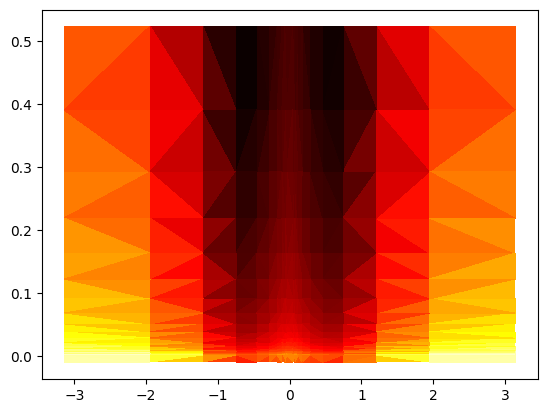

In [2]:
# download AIA full disk map
start_time = Time('2022-10-23T08:00:00', scale='utc', format='isot')
wavelength = '171'
jsoc_email = 'chuanpeng.hou@pku.edu.cn'
query = Fido.search(
    a.Time(start_time - 5*60*u.s, start_time + 5*60*u.s),
    a.Wavelength(int(wavelength)*u.angstrom),
    a.Sample(12*u.s),
    a.jsoc.Series.aia_lev1_euv_12s,
    a.jsoc.Notify(jsoc_email),
    a.jsoc.Segment.image,
)
dir_files = 'D:/work/wavelet/data/AIA/' + wavelength + '/'
# files = Fido.fetch(query, path=dir_files, overwrite=True)

files = list(np.sort(os.listdir(dir_files)))
sequence_raw = []
for file in files:
    sequence_raw.append(sunpy.map.Map(dir_files+file))

# calibrate AIA map
# calibrated_sequence = calibrate_aia_map_sequence(sequence_raw)
calibrated_sequence = sequence_raw

# transform to radial_theta coordinate
projected_sequence = project_aia_map(calibrated_sequence)

# crop map sequence
sub_radial_Rs_arr, sub_azimuth_arr, sequence_map_datetime, subsequence_data =\
            crop_lasco_map(projected_sequence, deg_min=1, deg_max=45, r_min=1.01, r_max=1.2)

# save croped map sequence
save_current_crop_sequence_data(sub_radial_Rs_arr, sub_azimuth_arr, subsequence_data)

# wavelet map sequence
calculate_wavelet_2DT_GPU(subsequence_data)

# combine wavelet results
azimuth_degree = 30.0
radial_Rs = 1.1 # can be ignored
# time_datetime = datetime.datetime(2023,11,14,0,0,0)
combine_wavelet_output(azimuth_degree, radial_Rs)

# visualize results
wavelet_output_combined_data = loadmat('D:/work/wavelet/data/wavelet_output_combined/combined_wavelet_output_azimuth_30.0_radial_1.1.mat')
wavelet_output_data = wavelet_output_combined_data['data']
print(wavelet_output_combined_data.keys())
lambda_r_arr = wavelet_output_combined_data['lambda_r_arr'][-1]
period_arr = wavelet_output_combined_data['period_arr'][-1]

omega_arr = 2*np.pi/(period_arr)
wavevector_arr = 2*np.pi/(lambda_r_arr*0.0012445220250452197)
wavelet_ouput_plot = np.sqrt(wavelet_output_data[30,0,:,:])
wavevector_grid, omega_grid = np.meshgrid(wavevector_arr, omega_arr, indexing='ij')

plt.tricontourf(wavevector_grid.reshape(-1),omega_grid.reshape(-1),wavelet_ouput_plot.reshape(-1),cmap='jet',levels=30,vmin=np.min(wavelet_ouput_plot)/400,vmax=np.max(wavelet_ouput_plot)/2)
plt.ylim([0.05,0.5])
plt.title('r = ' + '%3.2f'%(sub_radial_Rs_arr[30]) + ' Rs')
plt.xlabel(r'$k_{r}$  $ [2\pi/R_s]$')
plt.ylabel(r'$\omega$  $[2\pi/s]$')
# plt.pcolor(wavevector_arr,omega_arr,wavelet_ouput_plot, cmap='jet')



current_point_is_in_wavelet_output True
output_2DT_partial_0_lambda_r_0_lambda_t_0_period.mat
output_2DT_partial_0_lambda_r_0_lambda_t_1_period.mat


C:\Users\hcp\AppData\Local\Temp\ipykernel_28748\2125400158.py:205: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sub_idx = np.append(sub_idx, int(np.where(np.abs(array-i)<1e-3)[-1]))


output_2DT_partial_0_lambda_r_0_lambda_t_2_period.mat
output_2DT_partial_0_lambda_r_0_lambda_t_3_period.mat
output_2DT_partial_0_lambda_r_0_lambda_t_4_period.mat
output_2DT_partial_0_lambda_r_1_lambda_t_0_period.mat
output_2DT_partial_0_lambda_r_1_lambda_t_1_period.mat
output_2DT_partial_0_lambda_r_1_lambda_t_2_period.mat
output_2DT_partial_0_lambda_r_1_lambda_t_3_period.mat
output_2DT_partial_0_lambda_r_1_lambda_t_4_period.mat
output_2DT_partial_0_lambda_r_2_lambda_t_0_period.mat
output_2DT_partial_0_lambda_r_2_lambda_t_1_period.mat
output_2DT_partial_0_lambda_r_2_lambda_t_2_period.mat
output_2DT_partial_0_lambda_r_2_lambda_t_3_period.mat
output_2DT_partial_0_lambda_r_2_lambda_t_4_period.mat
output_2DT_partial_0_lambda_r_3_lambda_t_0_period.mat
output_2DT_partial_0_lambda_r_3_lambda_t_1_period.mat
output_2DT_partial_0_lambda_r_3_lambda_t_2_period.mat
output_2DT_partial_0_lambda_r_3_lambda_t_3_period.mat
output_2DT_partial_0_lambda_r_3_lambda_t_4_period.mat
output_2DT_partial_0_lambda_

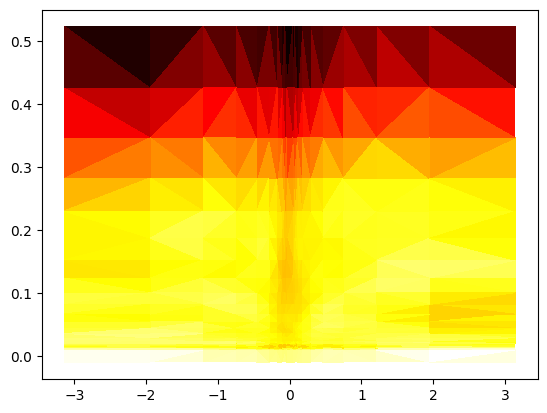

In [3]:
# combine wavelet results
azimuth_degree = 30.0
radial_Rs = 1.1 # can be ignored
# time_datetime = datetime.datetime(2023,11,14,0,0,0)
combine_wavelet_output(azimuth_degree, radial_Rs)

# visualize results
wavelet_output_combined_data = loadmat('D:/work/wavelet/data/wavelet_output_combined/combined_wavelet_output_azimuth_30.0_radial_1.1.mat')
wavelet_output_data = wavelet_output_combined_data['data']
print(wavelet_output_combined_data.keys())
lambda_r_arr = wavelet_output_combined_data['lambda_r_arr'][-1]
period_arr = wavelet_output_combined_data['period_arr'][-1]

omega_arr = 2*np.pi/(period_arr)
wavevector_arr = 2*np.pi/(lambda_r_arr*0.0012445220250452197)
wavelet_ouput_plot = np.sqrt(wavelet_output_data[30,0,:,:])
wavevector_grid, omega_grid = np.meshgrid(wavevector_arr, omega_arr, indexing='ij')

plt.tricontourf(wavevector_grid.reshape(-1),omega_grid.reshape(-1),wavelet_ouput_plot.reshape(-1),cmap='jet',levels=30,vmin=np.min(wavelet_ouput_plot)/400,vmax=np.max(wavelet_ouput_plot)/2)
plt.ylim([0.05,0.5])
plt.title('r = ' + '%3.2f'%(sub_radial_Rs_arr[30]) + ' Rs')
plt.xlabel(r'$k_{r}$  $ [2\pi/R_s]$')
plt.ylabel(r'$\omega$  $[2\pi/s]$')
# plt.pcolor(wavevector_arr,omega_arr,wavelet_ouput_plot, cmap='jet')



dict_keys(['__header__', '__version__', '__globals__', 'data', 'radial_arr', 'lambda_r_arr', 'lambda_t_arr', 'period_arr'])


Text(0, 0.5, '$\\omega$  $[2\\pi/s]$')

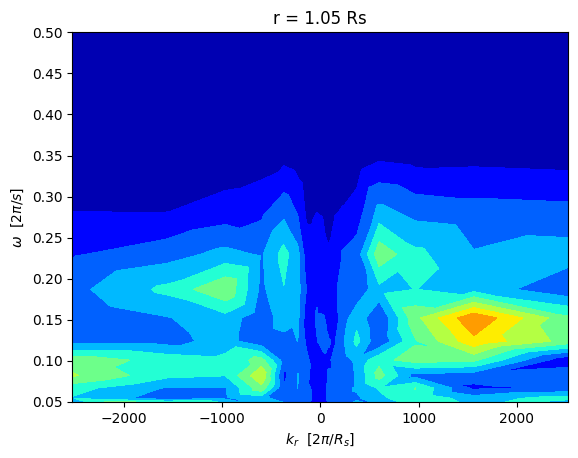

In [112]:
# visualize results
wavelet_output_combined_data = loadmat('D:/work/wavelet/data/wavelet_output_combined/combined_wavelet_output_azimuth_30.0_radial_1.1.mat')
wavelet_output_data = wavelet_output_combined_data['data']
print(wavelet_output_combined_data.keys())
lambda_r_arr = wavelet_output_combined_data['lambda_r_arr'][-1]
period_arr = wavelet_output_combined_data['period_arr'][-1]

omega_arr = 2*np.pi/(period_arr)
wavevector_arr = 2*np.pi/(lambda_r_arr*0.0012445220250452197)
wavelet_ouput_plot = np.sqrt(wavelet_output_data[30,0,:,:])
wavevector_grid, omega_grid = np.meshgrid(wavevector_arr, omega_arr, indexing='ij')

plt.tricontourf(wavevector_grid.reshape(-1),omega_grid.reshape(-1),wavelet_ouput_plot.reshape(-1),cmap='jet',levels=30,vmin=np.min(wavelet_ouput_plot)/400,vmax=np.max(wavelet_ouput_plot)/2)
plt.ylim([0.05,0.5])
plt.title('r = ' + '%3.2f'%(sub_radial_Rs_arr[30]) + ' Rs')
plt.xlabel(r'$k_{r}$  $ [2\pi/R_s]$')
plt.ylabel(r'$\omega$  $[2\pi/s]$')
# plt.pcolor(wavevector_arr,omega_arr,wavelet_ouput_plot, cmap='jet')


In [84]:
sequence_raw[0].scale[0].to_value('arcsec/pix')*2

1.198977948

In [51]:
np.abs(np.tan(1.2/3600/180*np.pi)*sequence_raw[0].fits_header['DSUN_OBS']/sequence_raw[0].fits_header['RSUN_REF'])

0.0012445220250452197

Text(0.5, 1.0, 'AIA 171 $\\AA$')

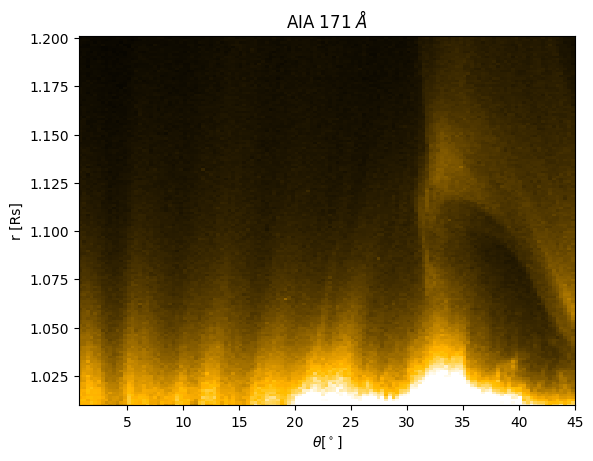

In [133]:
plt.pcolor(sub_azimuth_arr,sub_radial_Rs_arr,(subsequence_data[:,:,20]),cmap='sdoaia171',vmin=0,vmax=600)
plt.xlabel(r'$\theta [^\circ]$')
plt.ylabel('r [Rs]')
plt.title('AIA 171 $\AA$')

In [134]:
! open .

'open' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���
